# Chest X-Ray Pneumonia Classification - 2D CNN

### Cell order:
1. GPU Check
2. Package Versions
3. Mount Google Drive
4. Imports
5. Load Data
6. Visualize Class Distribution
7. Weighted Binary Cross-Entropy Loss
8. Build CNN Model
9. Train Model
10. Plot Training History
11. Evaluate on Test Set
12. Download Results

## Cell 1 - GPU Check


In [ ]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'GPU available: {gpus}')
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print('No GPU detected - running on CPU (slower)')
    print('Go to: Runtime -> Change runtime type -> T4 GPU')

print(f'TensorFlow version: {tf.__version__}')

GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TensorFlow version: 2.20.0


## Cell 2 - Package Versions

In [ ]:
import sklearn, pandas, numpy, seaborn

print(f'scikit-learn : {sklearn.__version__}')
print(f'pandas       : {pandas.__version__}')
print(f'numpy        : {numpy.__version__}')
print(f'seaborn      : {seaborn.__version__}')
print(f'tensorflow   : {tf.__version__}')
print('All packages available')

scikit-learn : 1.6.1
pandas       : 2.2.2
numpy        : 2.0.2
seaborn      : 0.13.2
tensorflow   : 2.20.0
All packages available


## Cell 3 - Mount Google Drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DATASET_PATH = '/content/drive/MyDrive/Datasets/chest_xray'

train_dir = f'{DATASET_PATH}/train'
test_dir  = f'{DATASET_PATH}/test'

import os
print(f'Train NORMAL    : {len(os.listdir(train_dir + "/NORMAL"))} images')
print(f'Train PNEUMONIA : {len(os.listdir(train_dir + "/PNEUMONIA"))} images')
print(f'Test  NORMAL    : {len(os.listdir(test_dir  + "/NORMAL"))} images')
print(f'Test  PNEUMONIA : {len(os.listdir(test_dir  + "/PNEUMONIA"))} images')

Mounted at /content/drive
Train NORMAL    : 1341 images
Train PNEUMONIA : 3875 images
Test  NORMAL    : 234 images
Test  PNEUMONIA : 390 images


## Cell 4 - Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

import keras
from keras.models import Sequential
from keras.layers import (
    Dense, Conv2D, MaxPool2D, Flatten,
    Dropout, BatchNormalization, GlobalAveragePooling2D
)
from keras.optimizers import Adam
from keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc
)
from sklearn.utils import class_weight

tf.random.set_seed(42)
np.random.seed(42)

os.makedirs('figures', exist_ok=True)
print('All imports successful')

All imports successful


## Cell 5 - Load Data

Heavier augmentation on Normal data since there's almost 3x more Pneumonia values in dataset, which led to extremely poor accuracy results.

Entire dataset did include Validation subset, but I didn't use it since it only has 16 photos, too little to properly run the experiment using only that for validation.

In [ ]:
IMG_HEIGHT = 150
IMG_WIDTH  = 150
BATCH_SIZE = 32

pneumonia_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=10,
    zoom_range=0.1,
    validation_split=0.2
)

normal_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    vertical_flip=False,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.1,
    brightness_range=[0.8, 1.2],
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_data = pneumonia_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    seed=42
)

val_data = pneumonia_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    seed=42
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print(f'\nClass indices: {train_data.class_indices}')
print(f'Train batches : {len(train_data)}')
print(f'Val batches   : {len(val_data)}')
print(f'Test batches  : {len(test_data)}')

Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.
Found 624 images belonging to 2 classes.

Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}
Train batches : 131
Val batches   : 33
Test batches  : 20


## Cell 6 - Visualize Class Distribution
Confirm the imbalance before training.

Training set class distribution:
  Normal    : 1073 (25.7%)
  Pneumonia : 3100 (74.3%)
  Ratio     : 1 : 2.9


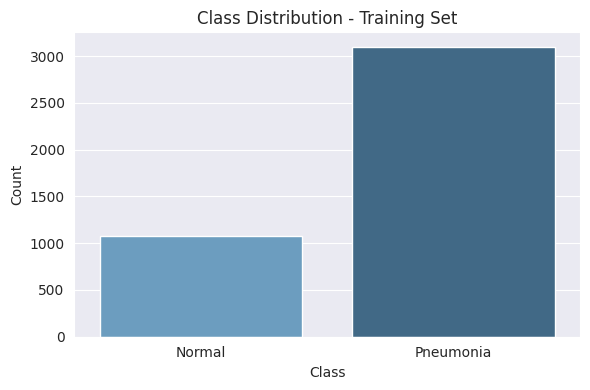

In [ ]:
labels = ['Normal' if c == 0 else 'Pneumonia' for c in train_data.classes]

n_normal    = sum(1 for c in train_data.classes if c == 0)
n_pneumonia = sum(1 for c in train_data.classes if c == 1)
total       = len(train_data.classes)

print(f'Training set class distribution:')
print(f'  Normal    : {n_normal:4d} ({100*n_normal/total:.1f}%)')
print(f'  Pneumonia : {n_pneumonia:4d} ({100*n_pneumonia/total:.1f}%)')
print(f'  Ratio     : 1 : {n_pneumonia/n_normal:.1f}')

sns.set_style('darkgrid')
plt.figure(figsize=(6, 4))
sns.countplot(x=labels, palette='Blues_d')
plt.title('Class Distribution - Training Set')
plt.xlabel('Class')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('figures/class_distribution.png', dpi=150)
plt.show()

## Cell 7 - Weighted Binary Cross-Entropy Loss

I've tried using class_weight to offset the imbalance, but the weights are applied inconsistently across batches because the generator does not guarantee that each batch contains both classes in the expected ratio. In practice this caused the model to ignore the weighting almost entirely.

The fix is a custom loss function that embeds the class weight directly into the gradient computation, so it is applied correctly on every single sample regardless of how the generator batches them.

In [ ]:
n_normal    = np.sum(train_data.classes == 0)
n_pneumonia = np.sum(train_data.classes == 1)

pos_weight = n_normal / n_pneumonia

print(f'Normal samples    : {n_normal}')
print(f'Pneumonia samples : {n_pneumonia}')
print(f'pos_weight        : {pos_weight:.4f}  (applied to Pneumonia/positive class)')

def weighted_bce(y_true, y_pred):
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
    loss = -(pos_weight * y_true  * tf.math.log(y_pred)
             +           (1 - y_true) * tf.math.log(1 - y_pred))
    return tf.reduce_mean(loss)

print('weighted_bce loss function defined')

Normal samples    : 1073
Pneumonia samples : 3100
pos_weight        : 0.3461  (applied to Pneumonia/positive class)
weighted_bce loss function defined


## Cell 8 - Build CNN Model


In [ ]:
model = Sequential([
    tf.keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

    # Block 1
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPool2D((2, 2)),
    Dropout(0.25),

    # Block 2
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPool2D((2, 2)),
    Dropout(0.25),

    # Block 3
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPool2D((2, 2)),
    Dropout(0.25),

    # Block 4
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPool2D((2, 2)),
    Dropout(0.25),

    GlobalAveragePooling2D(),

    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=weighted_bce,
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 18, 18, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 457,409 (1.74 MB)

 Trainable params: 455,937 (1.74 MB)

 Non-trainable params: 1,472 (5.75 KB)

## Cell 9 - Train Model


In [ ]:
lr_reduction = ReduceLROnPlateau(
    monitor='val_loss',
    patience=5,
    factor=0.5,
    min_lr=1e-6,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    train_data,
    epochs=30,
    validation_data=val_data,
    callbacks=[lr_reduction, early_stop]
)

print('Training complete')

Epoch 1/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 1869s 14s/step - accuracy: 0.8107 - auc: 0.9172 - loss: 0.2002 - val_accuracy: 0.7430 - val_auc: 0.5000 - val_loss: 2.2724 - learning_rate: 0.0010
Epoch 2/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 90s 692ms/step - accuracy: 0.8864 - auc: 0.9598 - loss: 0.1333 - val_accuracy: 0.7430 - val_auc: 0.5000 - val_loss: 2.8094 - learning_rate: 0.0010
Epoch 3/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 93s 707ms/step - accuracy: 0.9149 - auc: 0.9706 - loss: 0.1110 - val_accuracy: 0.7430 - val_auc: 0.5000 - val_loss: 3.4311 - learning_rate: 0.0010
Epoch 4/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 91s 694ms/step - accuracy: 0.9276 - auc: 0.9771 - loss: 0.0980 - val_accuracy: 0.7430 - val_auc: 0.5000 - val_loss: 4.0964 - learning_rate: 0.0010
Epoch 5/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 92s 700ms/step - accuracy: 0.9245 - auc: 0.9770 - loss: 0.0980 - val_accuracy: 0.7430 - val_auc: 0.5000 - val_loss: 2.7334 - learning_rate: 0.0010
Epoch 6/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 91s 694ms/step - accuracy

## Cell 10 - Plot Training History

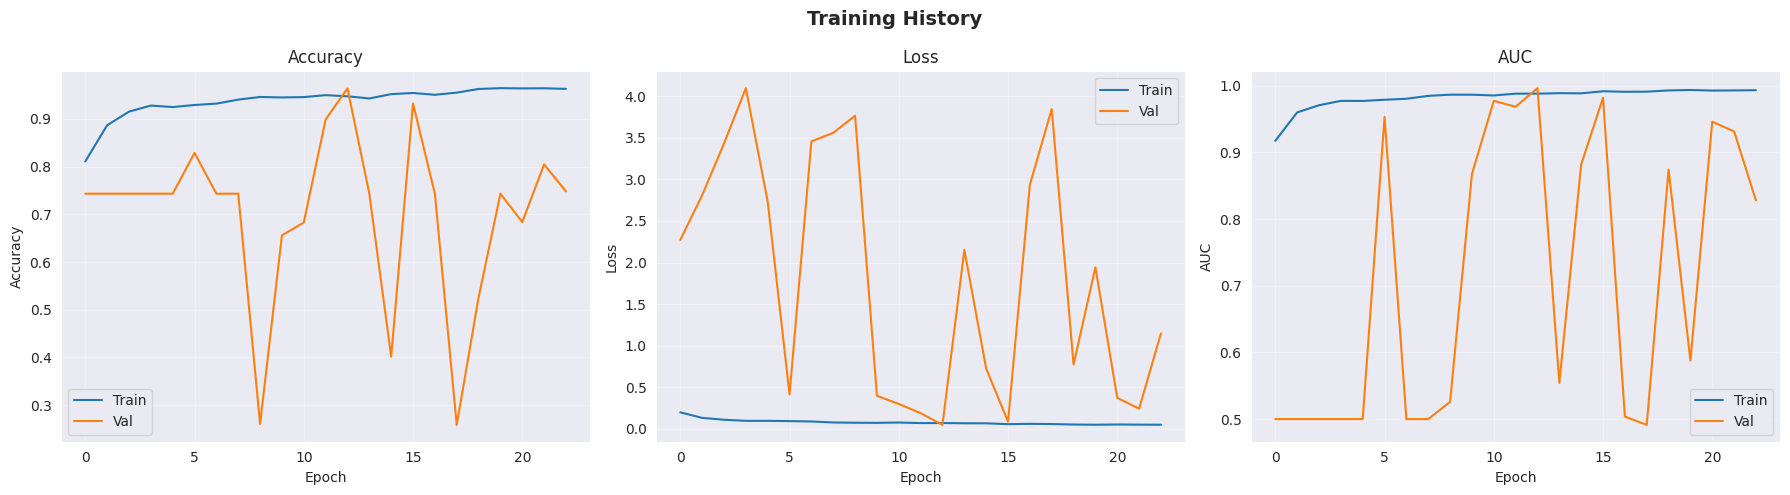

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training History', fontsize=14, fontweight='bold')

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Val')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# AUC
axes[2].plot(history.history['auc'],     label='Train')
axes[2].plot(history.history['val_auc'], label='Val')
axes[2].set_title('AUC')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('AUC')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/training_history.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 11 - Evaluate on Test Set

Optimal decision threshold found via Youden's J statistic.

20/20 ━━━━━━━━━━━━━━━━━━━━ 193s 10s/step
ROC AUC Score      : 0.9568
Optimal threshold  : 0.5559  (default would be 0.5)


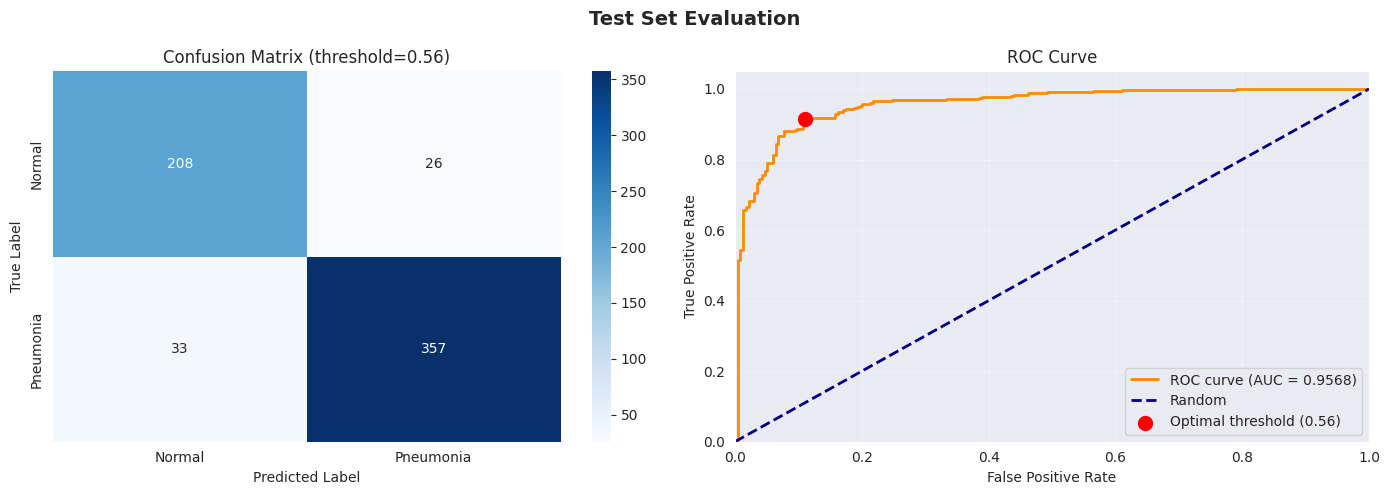


--- Classification Report ---
              precision    recall  f1-score   support

      Normal       0.86      0.89      0.88       234
   Pneumonia       0.93      0.92      0.92       390

    accuracy                           0.91       624
   macro avg       0.90      0.90      0.90       624
weighted avg       0.91      0.91      0.91       624

Sensitivity (Pneumonia recall) : 0.9154
Specificity (Normal recall)    : 0.8889
ROC AUC                        : 0.9568


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

test_labels  = test_data.classes
predictions  = model.predict(test_data, verbose=1).flatten()

fpr, tpr, thresholds = roc_curve(test_labels, predictions)
roc_auc = auc(fpr, tpr)

optimal_idx       = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print(f'ROC AUC Score      : {roc_auc:.4f}')
print(f'Optimal threshold  : {optimal_threshold:.4f}  (default would be 0.5)')

predicted_classes = (predictions >= optimal_threshold).astype(int)

# --- Confusion matrix ---
cm = confusion_matrix(test_labels, predicted_classes)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Test Set Evaluation', fontsize=14, fontweight='bold')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'])
axes[0].set_title(f'Confusion Matrix (threshold={optimal_threshold:.2f})')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# ROC curve
axes[1].plot(fpr, tpr, color='darkorange', lw=2,
             label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
axes[1].scatter(fpr[optimal_idx], tpr[optimal_idx],
                marker='o', color='red', s=100,
                label=f'Optimal threshold ({optimal_threshold:.2f})', zorder=5)
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/test_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

# Classification report
print('\n--- Classification Report ---')
print(classification_report(test_labels, predicted_classes,
      target_names=['Normal', 'Pneumonia']))

tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)  # recall for Pneumonia
specificity = tn / (tn + fp)  # recall for Normal
print(f'Sensitivity (Pneumonia recall) : {sensitivity:.4f}')
print(f'Specificity (Normal recall)    : {specificity:.4f}')
print(f'ROC AUC                        : {roc_auc:.4f}')

## Cell 12 - Download Results


In [ ]:
from google.colab import files

model.save('xray_cnn_model.keras')

files.download('figures/training_history.png')
files.download('figures/test_evaluation.png')
files.download('figures/class_distribution.png')
files.download('xray_cnn_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>